# Big Data y Minería de Datos — Dataset SIVIGILA  
## Identificación de Perfiles de Riesgo en Registros de Intento de Suicidio
**Metodología:** CRISP-DM | **Infraestructura:** AWS (S3 · Glue · Step Functions · Athena)  
**Institución Universitaria Salazar y Herrera** | Abril 2026

---

### Arquitectura del proyecto
```
Bronze (CSV original)
    └─► Silver (limpieza, normalización)    [AWS Glue Job 1]
            └─► Gold (tablas analíticas)    [AWS Glue Job 2]
                    └─► Modelado CRISP-DM   [este notebook]
```

### Fases CRISP-DM cubiertas
| # | Fase | Resultado |
|---|------|-----------|
| 1 | Comprensión del negocio | Contexto y preguntas analíticas |
| 2 | Comprensión de los datos | EDA + estadísticas + visualizaciones |
| 3 | Calidad y validación | Reporte de calidad estructurado |
| 4 | Preparación de datos | Dataset Silver + feature engineering |
| 5 | Construcción Gold | Tablas agregadas y de perfil de riesgo |
| 6 | Modelado — Clasificación | 4 algoritmos supervisados |
| 7 | Modelado — Segmentación | K-Means + análisis de clusters |
| 8 | Evaluación | Métricas, matrices, curvas ROC |
| 9 | Interpretación y valor | Importancia de variables + perspectiva de salud pública |

---
## Sección 1 — Configuración del entorno y librerías

In [1]:
import os, warnings, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
    classification_report, silhouette_score
)

warnings.filterwarnings('ignore')
np.random.seed(42)

# Rutas
BASE_DIR = Path("Big Data AWS")
CSV_PATH = BASE_DIR / "sivigila_intsuicidio.csv"
OUTPUT_DIR = Path("output_mineria")
OUTPUT_DIR.mkdir(exist_ok=True)

print(f"CSV fuente : {CSV_PATH}")
print(f"Existe     : {CSV_PATH.exists()}")
print(f"Output dir : {OUTPUT_DIR.resolve()}")

CSV fuente : Big Data AWS\sivigila_intsuicidio.csv
Existe     : True
Output dir : C:\Users\USUARIO\OneDrive - INSTITUCION UNIVERSITARIA SALAZAR Y HERRERA\Escritorio\Suicidios Big Data Proyecto\output_mineria


---
## Sección 2 — Carga de datos desde Bronze (CSV SIVIGILA)

El dataset `sivigila_intsuicidio.csv` representa la capa **Bronze** del pipeline: datos crudos tal como llegan desde la fuente. Contiene registros de intento de suicidio con variables demográficas, clínicas y psicosociales.

**Variables disponibles:** `id`, `edad`, `sexo`, `nombre_barrio`, `comuna`, `year`, `pac_hos` (hospitalización), factores de riesgo binarios, métodos de intento, atención recibida.

In [2]:
# ── Leer CSV Bronze ──────────────────────────────────────────
df_bronze = pd.read_csv(CSV_PATH, sep=';', dtype=str, encoding='utf-8')

# Normalizar nombres de columnas
df_bronze.columns = [c.strip().lower().replace(' ', '_') for c in df_bronze.columns]

print(f"Dimensiones Bronze : {df_bronze.shape[0]} filas × {df_bronze.shape[1]} columnas")
print(f"\nColumnas ({len(df_bronze.columns)}):")
for i, col in enumerate(df_bronze.columns, 1):
    print(f"  {i:02d}. {col}")

print("\nPrimeras 5 filas:")
df_bronze.head()

Dimensiones Bronze : 13699 filas × 46 columnas

Columnas (46):
  01. id
  02. edad
  03. sexo
  04. nombre_barrio
  05. comuna
  06. year
  07. fec_con
  08. ini_sin
  09. tip_cas
  10. pac_hos
  11. inten_prev
  12. intentos
  13. estado_civ
  14. escolarid
  15. prob_parej
  16. enfermedad_cronica
  17. prob_econo
  18. muerte_fam
  19. esco_educ
  20. prob_legal
  21. suici_fm_a
  22. maltr_fps
  23. prob_labor
  24. prob_consu
  25. hist_famil
  26. idea_suici
  27. plan_suici
  28. antec_tran
  29. tran_depre
  30. trast_personalidad
  31. trast_bipolaridad
  32. esquizofre
  33. antec_v_a
  34. abuso_alco
  35. ahorcamien
  36. arma_corto
  37. arma_fuego
  38. inmolacion
  39. lanz_vacio
  40. lanz_vehic
  41. lanz_agua
  42. intoxicaci
  43. gp_psiquia
  44. psiquiatri
  45. trab_socia
  46. evento

Primeras 5 filas:


,id,edad,sexo,nombre_barrio,comuna,year,fec_con,ini_sin,tip_cas,pac_hos,...,arma_fuego,inmolacion,lanz_vacio,lanz_vehic,lanz_agua,intoxicaci,gp_psiquia,psiquiatri,trab_socia,evento
0,1,22,F,Santo Domingo Savio No.1,Popular,2015,8/12/2015,8/12/2015,4,1,...,SD,SD,SD,SD,SD,SD,SD,SD,SD,INTENTO DE SUICIDIO
1,2,19,M,Villa Hermosa,Villa Hermosa,2015,7/12/2015,7/12/2015,4,1,...,SD,SD,SD,SD,SD,SD,SD,SD,SD,INTENTO DE SUICIDIO
2,3,52,F,Los Conquistadores,Laureles,2015,7/12/2015,7/12/2015,4,2,...,SD,SD,SD,SD,SD,SD,SD,SD,SD,INTENTO DE SUICIDIO
3,4,58,F,Las Violetas,Belen,2015,7/12/2015,6/12/2015,4,2,...,SD,SD,SD,SD,SD,SD,SD,SD,SD,INTENTO DE SUICIDIO
4,5,32,M,Florida Nueva,Laureles,2015,6/12/2015,6/12/2015,4,1,...,SD,SD,SD,SD,SD,SD,SD,SD,SD,INTENTO DE SUICIDIO


---
## Sección 3 — Perfilado inicial y validación de calidad

Se identifican nulos, valores `SD` (sin dato), duplicados y rangos. El marcador `SD` equivale a dato faltante en este dataset y debe tratarse como `NaN`.  
Esta sección corresponde a la fase **Comprensión de los Datos** de CRISP-DM.

  REPORTE DE CALIDAD — DATASET BRONZE
  Registros totales  : 13,699
  Columnas           : 46
  Duplicados exactos : 0
                    valores_SD  nulos  pct_sin_dato  valores_unicos
intentos                 11014      0          80.4               6
trast_personalidad       10773      0          78.6               3
trast_bipolaridad        10450      0          76.3               3
esquizofre               10449      0          76.3               3
tran_depre               10450      0          76.3               3
abuso_alco                9682      0          70.7               3
prob_consu                9233      0          67.4               3
lanz_agua                 7188      0          52.5               3
muerte_fam                7182      0          52.4               3
estado_civ                7182      0          52.4               6
escolarid                 7182      0          52.4              15
antec_v_a                 7183      0          52.4              

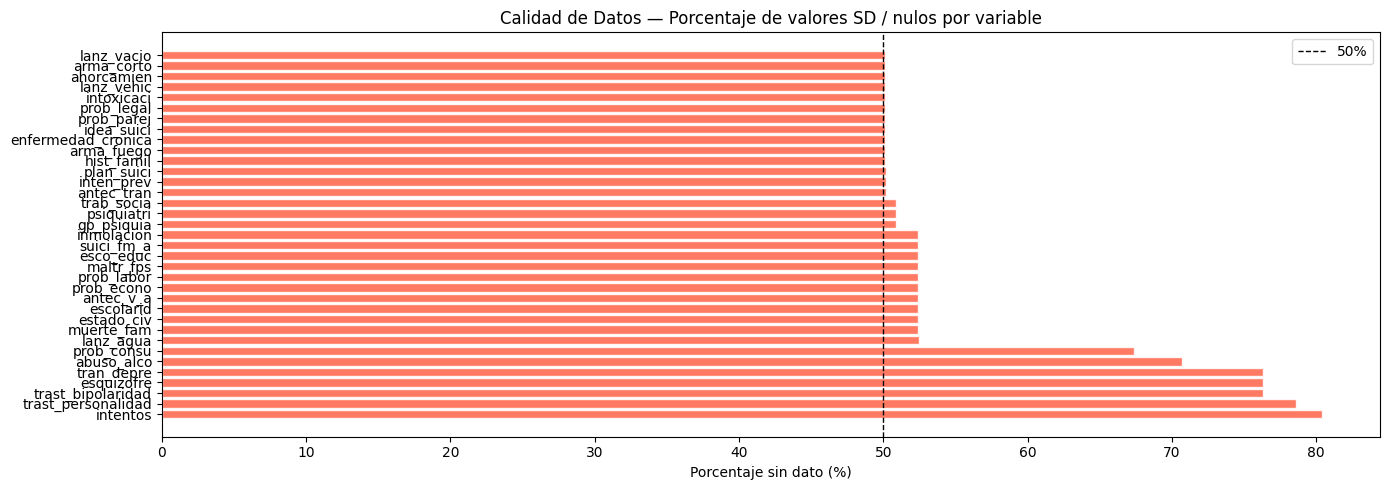

In [3]:
INVALID_MARKERS = {'SD', 'sd', 'NA', 'N/A', 'null', 'NULL', 'none', 'NONE', '-', ''}

def contar_sin_dato(serie):
    return serie.apply(lambda x: str(x).strip().upper() in {m.upper() for m in INVALID_MARKERS}).sum()

# ── Reporte de calidad ────────────────────────────────────────
reporte = pd.DataFrame({
    'nulos':         df_bronze.isnull().sum(),
    'valores_SD':    df_bronze.apply(contar_sin_dato),
    'valores_unicos':df_bronze.nunique(),
    'dtype':         df_bronze.dtypes
})
reporte['total_sin_dato'] = reporte['nulos'] + reporte['valores_SD']
reporte['pct_sin_dato']   = (reporte['total_sin_dato'] / len(df_bronze) * 100).round(1)
reporte = reporte.sort_values('pct_sin_dato', ascending=False)

print("=" * 65)
print("  REPORTE DE CALIDAD — DATASET BRONZE")
print("=" * 65)
print(f"  Registros totales  : {len(df_bronze):,}")
print(f"  Columnas           : {len(df_bronze.columns)}")
print(f"  Duplicados exactos : {df_bronze.duplicated().sum():,}")
print("=" * 65)
print(reporte[['valores_SD','nulos','pct_sin_dato','valores_unicos']].to_string())

# Visualizar porcentaje de sin dato por variable
fig, ax = plt.subplots(figsize=(14, 5))
cols_con_sd = reporte[reporte['pct_sin_dato'] > 0]
ax.barh(cols_con_sd.index, cols_con_sd['pct_sin_dato'], color='tomato', edgecolor='white', alpha=0.85)
ax.axvline(x=50, color='black', linestyle='--', linewidth=1, label='50%')
ax.set_xlabel('Porcentaje sin dato (%)')
ax.set_title('Calidad de Datos — Porcentaje de valores SD / nulos por variable')
ax.legend()
plt.tight_layout()
plt.show()

---
## Sección 4 — Limpieza y estandarización → capa Silver

Equivale al **Job 1 de AWS Glue** ejecutado localmente. Se aplican:
- Reemplazo de marcadores inválidos por `NaN`
- Conversión de tipos (`edad` → float, `year` → int, `pac_hos` → int)
- Normalización de `sexo` a M / F
- Eliminación de duplicados y filas sin columnas críticas

In [4]:
df_silver = df_bronze.copy()

# ── 1. Reemplazar marcadores sin dato ────────────────────────
upper_invalids = {m.upper() for m in INVALID_MARKERS}
for col in df_silver.columns:
    df_silver[col] = df_silver[col].apply(
        lambda x: np.nan if str(x).strip().upper() in upper_invalids else x
    )

# ── 2. Tipos ─────────────────────────────────────────────────
df_silver['edad']    = pd.to_numeric(df_silver['edad'],    errors='coerce')
df_silver['year']    = pd.to_numeric(df_silver['year'],    errors='coerce').astype('Int64')
df_silver['pac_hos'] = pd.to_numeric(df_silver['pac_hos'], errors='coerce')

# ── 3. Normalizar sexo ───────────────────────────────────────
df_silver['sexo'] = df_silver['sexo'].str.strip().str.upper()
df_silver.loc[~df_silver['sexo'].isin(['M', 'F']), 'sexo'] = np.nan

# ── 4. Filtrar pac_hos válido y columnas críticas ────────────
df_silver = df_silver[df_silver['pac_hos'].isin([1, 2])]
antes = len(df_silver)
df_silver = df_silver.drop_duplicates()
df_silver = df_silver.dropna(subset=['edad', 'sexo', 'comuna', 'year'])
df_silver = df_silver.reset_index(drop=True)

print(f"Registros Bronze  : {len(df_bronze):,}")
print(f"Registros Silver  : {len(df_silver):,}")
print(f"Eliminados        : {len(df_bronze) - len(df_silver):,}")

print(f"\nRango de edad     : {df_silver['edad'].min():.0f} – {df_silver['edad'].max():.0f} años")
print(f"Años disponibles  : {sorted(df_silver['year'].dropna().unique().tolist())}")
print(f"\npac_hos (1=Hosp, 2=No hosp):")
print(df_silver['pac_hos'].value_counts().to_string())

# Guardar Silver
df_silver.to_parquet(OUTPUT_DIR / "silver_sivigila.parquet", index=False)
print(f"\n✓ Silver guardado en {OUTPUT_DIR / 'silver_sivigila.parquet'}")

Registros Bronze  : 13,699
Registros Silver  : 13,697
Eliminados        : 2

Rango de edad     : 5 – 90 años
Años disponibles  : [2013, 2014, 2015, 2016, 2017, 2018, 2019]

pac_hos (1=Hosp, 2=No hosp):
pac_hos
1.0    8829
2.0    4868

✓ Silver guardado en output_mineria\silver_sivigila.parquet


---
## Sección 5 — Construcción de tablas Gold

Equivale al **Job 2 de AWS Glue**. Se generan dos tablas analíticas:

- **`gold_resumen_comuna`** — Agrupación por comuna × año con totales, tasas y promedios.  
- **`gold_perfil_riesgo`** — Perfil individual con puntaje de riesgo calculado a partir de variables clínicas/psicosociales disponibles.

In [5]:
# ── GOLD 1: Resumen por comuna × año ─────────────────────────
gold_resumen = (
    df_silver.groupby(['comuna', 'year'])
    .agg(
        total_casos         = ('id', 'count'),
        total_hospitalizados= ('pac_hos', lambda x: (x == 1).sum()),
        edad_promedio       = ('edad', 'mean'),
        casos_masculino     = ('sexo', lambda x: (x == 'M').sum()),
        casos_femenino      = ('sexo', lambda x: (x == 'F').sum()),
    )
    .reset_index()
)
gold_resumen['pct_hospitalizados'] = (
    gold_resumen['total_hospitalizados'] / gold_resumen['total_casos'] * 100
).round(1)
gold_resumen['edad_promedio'] = gold_resumen['edad_promedio'].round(1)

# ── GOLD 2: Perfil de riesgo individual ──────────────────────
RISK_COLS = [
    'prob_parej', 'enfermedad_cronica', 'prob_econo', 'muerte_fam',
    'prob_legal', 'prob_labor', 'prob_consu', 'hist_famil',
    'idea_suici', 'plan_suici', 'antec_tran', 'tran_depre',
    'trast_personalidad', 'trast_bipolaridad', 'esquizofre',
    'abuso_alco', 'maltr_fps', 'antec_v_a'
]
existing_risk = [c for c in RISK_COLS if c in df_silver.columns]

gold_perfil = df_silver[['id', 'edad', 'sexo', 'comuna', 'year', 'pac_hos']].copy()

if existing_risk:
    gold_perfil['puntaje_riesgo'] = (
        df_silver[existing_risk]
        .apply(pd.to_numeric, errors='coerce')
        .fillna(0)
        .sum(axis=1)
        .astype(int)
    )
else:
    gold_perfil['puntaje_riesgo'] = 0

gold_perfil['nivel_riesgo'] = pd.cut(
    gold_perfil['puntaje_riesgo'],
    bins=[-1, 2, 5, 100],
    labels=['bajo', 'medio', 'alto']
)

# Guardar Gold
gold_resumen.to_parquet(OUTPUT_DIR / "gold_resumen_comuna.parquet",  index=False)
gold_perfil.to_parquet( OUTPUT_DIR / "gold_perfil_riesgo.parquet",   index=False)

print("=== GOLD 1: Resumen por comuna/año (primeras 10 filas) ===")
print(gold_resumen.head(10).to_string(index=False))
print(f"\nShape: {gold_resumen.shape}")

print("\n=== GOLD 2: Perfil de riesgo (primeras 10 filas) ===")
print(gold_perfil[['id','edad','sexo','puntaje_riesgo','nivel_riesgo','pac_hos']].head(10).to_string(index=False))
print(f"\nShape: {gold_perfil.shape}")
print(f"Variables de riesgo encontradas: {len(existing_risk)}/{len(RISK_COLS)}")

=== GOLD 1: Resumen por comuna/año (primeras 10 filas) ===
   comuna  year  total_casos  total_hospitalizados  edad_promedio  casos_masculino  casos_femenino  pct_hospitalizados
Altavista  2013           16                    11           24.1                7               9                68.8
Altavista  2014           11                     4           25.2                5               6                36.4
Altavista  2015           15                    11           21.8                7               8                73.3
Altavista  2016           15                    11           27.9                5              10                73.3
Altavista  2017           20                    11           20.2                4              16                55.0
Altavista  2018           19                    11           27.2                8              11                57.9
Altavista  2019           11                     4           27.5                2               9          

---
## Sección 6 — Análisis Exploratorio de Datos (EDA)

Fase **Comprensión de los Datos** de CRISP-DM. Se construyen visualizaciones sobre:  
distribución de edad, casos por sexo y año, top comunas, proporción de hospitalización y relación edad × hospitalización.

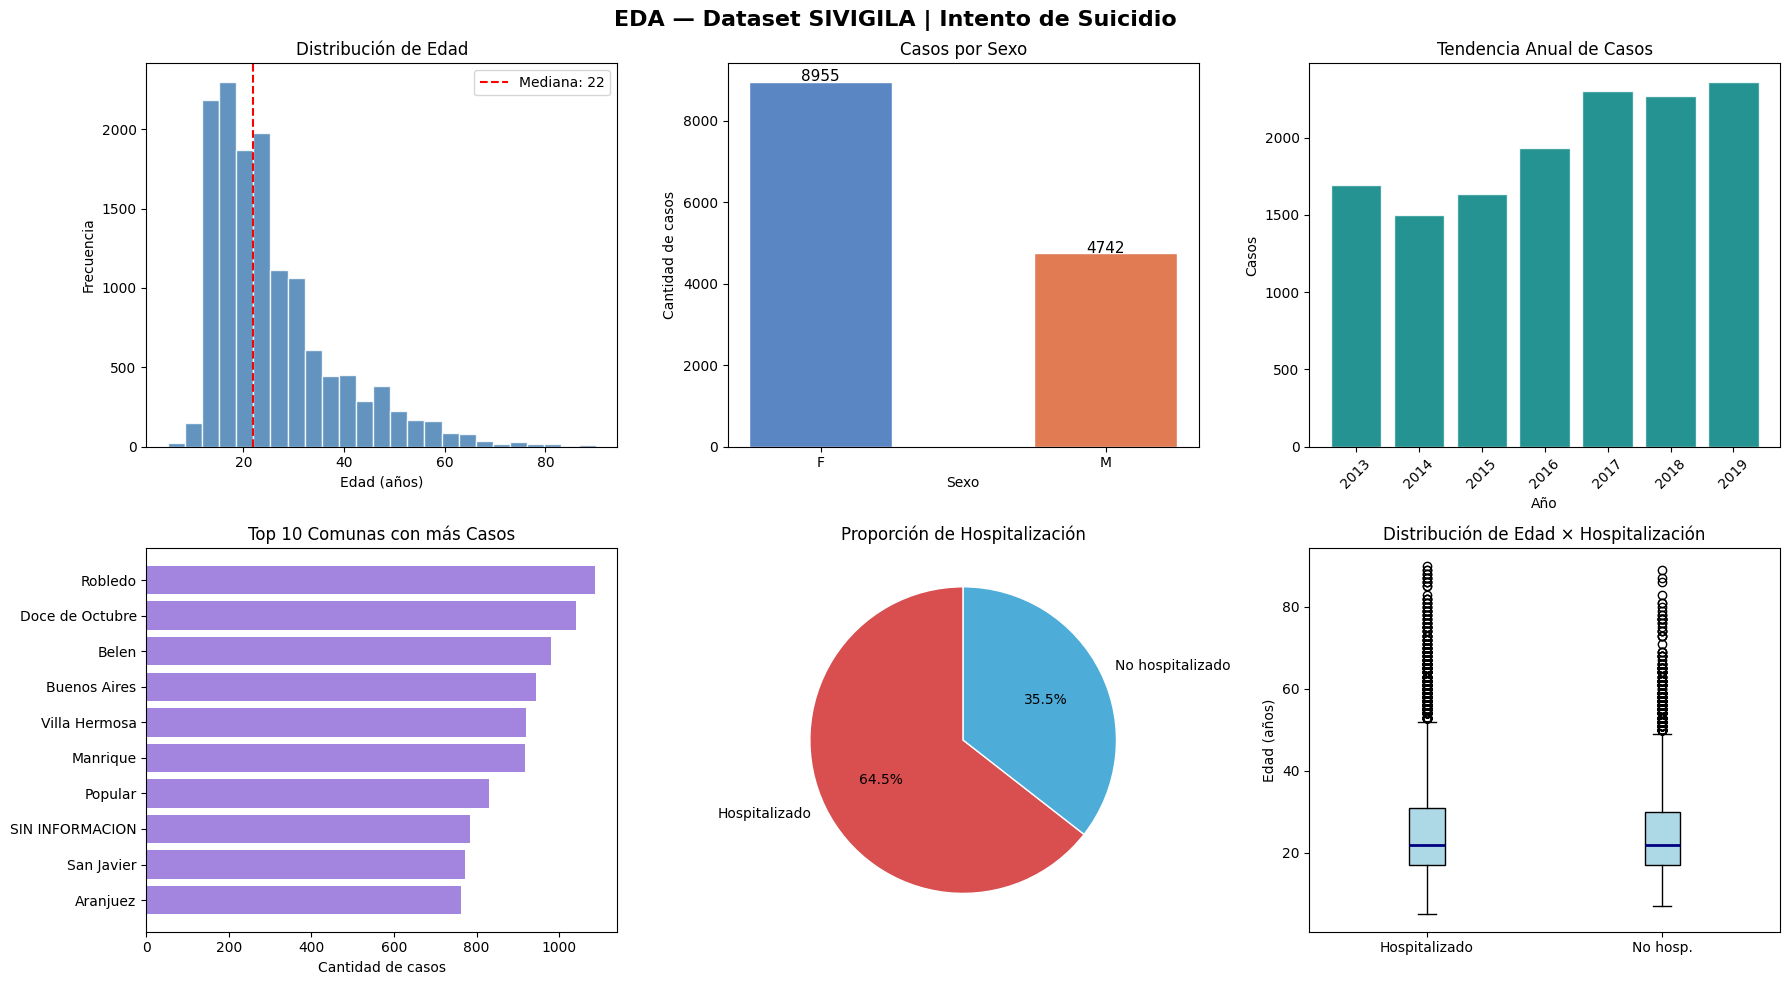


=== Estadísticas Descriptivas ===
           edad     year
count  13697.00  13697.0
mean      25.74  2016.31
std       12.32     1.99
min        5.00   2013.0
25%       17.00   2015.0
50%       22.00   2017.0
75%       31.00   2018.0
max       90.00   2019.0


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('EDA — Dataset SIVIGILA | Intento de Suicidio', fontsize=16, fontweight='bold')

hosp_map = {1: 'Hospitalizado', 2: 'No hospitalizado'}

# 1. Distribución de edad
axes[0,0].hist(df_silver['edad'].dropna(), bins=25, color='steelblue', edgecolor='white', alpha=0.85)
axes[0,0].set_title('Distribución de Edad')
axes[0,0].set_xlabel('Edad (años)')
axes[0,0].set_ylabel('Frecuencia')
axes[0,0].axvline(df_silver['edad'].median(), color='red', linestyle='--', label=f"Mediana: {df_silver['edad'].median():.0f}")
axes[0,0].legend()

# 2. Casos por sexo
sex_counts = df_silver['sexo'].value_counts()
bars = axes[0,1].bar(sex_counts.index, sex_counts.values, color=['#5b86c4','#e07b54'], edgecolor='white', width=0.5)
for bar, v in zip(bars, sex_counts.values):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, v + 5, str(v), ha='center', fontsize=11)
axes[0,1].set_title('Casos por Sexo')
axes[0,1].set_xlabel('Sexo')
axes[0,1].set_ylabel('Cantidad de casos')

# 3. Casos por año
year_counts = df_silver['year'].value_counts().sort_index()
axes[0,2].bar(year_counts.index.astype(str), year_counts.values, color='teal', edgecolor='white', alpha=0.85)
axes[0,2].set_title('Tendencia Anual de Casos')
axes[0,2].set_xlabel('Año')
axes[0,2].set_ylabel('Casos')
axes[0,2].tick_params(axis='x', rotation=45)

# 4. Top 10 comunas
top_comunas = df_silver['comuna'].value_counts().head(10)
axes[1,0].barh(top_comunas.index[::-1], top_comunas.values[::-1], color='mediumpurple', alpha=0.85)
axes[1,0].set_title('Top 10 Comunas con más Casos')
axes[1,0].set_xlabel('Cantidad de casos')

# 5. Proporción hospitalización
hosp_counts = df_silver['pac_hos'].map(hosp_map).value_counts()
axes[1,1].pie(
    hosp_counts, labels=hosp_counts.index, autopct='%1.1f%%',
    colors=['#d94e4e','#4eacd9'], startangle=90, wedgeprops={'edgecolor':'white'}
)
axes[1,1].set_title('Proporción de Hospitalización')

# 6. Boxplot edad por hospitalización
temp = df_silver.copy()
temp['Hospitalización'] = temp['pac_hos'].map(hosp_map)
grupos = [temp[temp['Hospitalización']==g]['edad'].dropna().values for g in ['Hospitalizado','No hospitalizado']]
bp = axes[1,2].boxplot(grupos, labels=['Hospitalizado','No hosp.'], patch_artist=True,
                      boxprops=dict(facecolor='lightblue'), medianprops=dict(color='navy', linewidth=2))
axes[1,2].set_title('Distribución de Edad × Hospitalización')
axes[1,2].set_ylabel('Edad (años)')

plt.tight_layout()
plt.show()

# Estadísticas descriptivas
print("\n=== Estadísticas Descriptivas ===")
print(df_silver[['edad','year']].describe().round(2))

---
## Sección 7 — Preparación del dataset para minería de datos

Fase **Preparación de los Datos** de CRISP-DM:

| Paso | Técnica |
|------|---------|
| Variable objetivo | `pac_hos`: 1 → hospitalizado (1), 2 → no hospitalizado (0) |
| Feature engineering | Grupo etario (cortes 0–17, 18–25, 26–35, 36–50, 51+) |
| Encoding categórico | `sexo`: binario M=1/F=0; `grupo_etario`: One-Hot encoding |
| Encoding por frecuencia | `comuna` → proporción relativa de casos |
| Escalamiento | `StandardScaler` sobre todas las features numéricas |
| División | 80 % entrenamiento – 20 % prueba, estratificada |

In [7]:
# ── Variable objetivo ────────────────────────────────────────
df_model = df_silver[['edad', 'sexo', 'comuna', 'year', 'pac_hos']].copy()
df_model['target'] = (df_model['pac_hos'] == 1).astype(int)
df_model = df_model.drop(columns=['pac_hos'])

# ── Feature engineering: grupo etario ────────────────────────
df_model['grupo_etario'] = pd.cut(
    df_model['edad'],
    bins=[0, 17, 25, 35, 50, 120],
    labels=['menor_17', 'joven_18_25', 'adulto_26_35', 'adulto_36_50', 'mayor_51']
)

# ── Encoding: sexo (binario) ─────────────────────────────────
df_model['sexo_enc'] = df_model['sexo'].map({'M': 1, 'F': 0})

# ── Encoding: comuna por frecuencia ──────────────────────────
freq_comuna = df_model['comuna'].value_counts(normalize=True)
df_model['freq_comuna'] = df_model['comuna'].map(freq_comuna)

# ── One-Hot: grupo etario ────────────────────────────────────
df_model = pd.get_dummies(df_model, columns=['grupo_etario'], drop_first=True)

# ── Dataset final ─────────────────────────────────────────────
feature_cols = (
    ['edad', 'sexo_enc', 'year', 'freq_comuna']
    + [c for c in df_model.columns if c.startswith('grupo_etario_')]
)
X = df_model[feature_cols].dropna()
y = df_model.loc[X.index, 'target']

# ── Escalamiento ──────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

# ── División 80-20 estratificada ─────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Total muestras : {len(X):,}")
print(f"Train          : {len(X_train):,}  ({len(X_train)/len(X)*100:.0f}%)")
print(f"Test           : {len(X_test):,}   ({len(X_test)/len(X)*100:.0f}%)")
print(f"\nBalance de clases — Test:")
print(y_test.value_counts().rename({1: 'Hospitalizado', 0: 'No hospitalizado'}).to_string())
print(f"\nFeatures ({len(feature_cols)}): {feature_cols}")

Total muestras : 13,697
Train          : 10,957  (80%)
Test           : 2,740   (20%)

Balance de clases — Test:
target
Hospitalizado       1766
No hospitalizado     974

Features (8): ['edad', 'sexo_enc', 'year', 'freq_comuna', 'grupo_etario_joven_18_25', 'grupo_etario_adulto_26_35', 'grupo_etario_adulto_36_50', 'grupo_etario_mayor_51']


---
## Sección 8 — Modelado de clasificación de riesgo

Fase **Modelado** de CRISP-DM. Se entrenan **4 modelos supervisados** con validación cruzada estratificada (5 folds):

1. **Regresión Logística** — modelo lineal, interpretable, buena línea base.
2. **Árbol de Decisión** — reglas explícitas, captura relaciones no lineales.
3. **Random Forest** — ensemble que mejora la varianza, robusto a ruido.
4. **K-Nearest Neighbors (KNN)** — clasificación por similitud sin supuestos paramétricos.

**Objetivo:** predecir si un paciente será hospitalizado (`pac_hos` = 1).

In [8]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

MODELOS = {
    'Regresion Logistica': LogisticRegression(max_iter=1000, C=1.0, random_state=42),
    'Arbol de Decision':   DecisionTreeClassifier(max_depth=6, min_samples_leaf=5, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, max_depth=8, random_state=42, n_jobs=-1),
    'KNN':                 KNeighborsClassifier(n_neighbors=7, metric='euclidean'),
}

resultados = {}
print("Entrenando modelos...\n")
print(f"{'Modelo':25s} | {'Accuracy':>8} | {'Precisión':>9} | {'Recall':>7} | {'F1':>7} | {'ROC-AUC':>8} | {'CV-F1':>7}")
print("-" * 85)

for nombre, modelo in MODELOS.items():
    modelo.fit(X_train, y_train)
    y_pred  = modelo.predict(X_test)
    y_proba = modelo.predict_proba(X_test)[:, 1] if hasattr(modelo, 'predict_proba') else None

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    auc  = roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan
    cvf1 = cross_val_score(modelo, X_scaled, y, cv=cv, scoring='f1').mean()

    resultados[nombre] = dict(
        modelo=modelo, y_pred=y_pred, y_proba=y_proba,
        accuracy=acc, precision=prec, recall=rec, f1=f1, roc_auc=auc, cv_f1=cvf1
    )
    print(f"{nombre:25s} | {acc:8.4f} | {prec:9.4f} | {rec:7.4f} | {f1:7.4f} | {auc:8.4f} | {cvf1:7.4f}")

print("\n✓ Todos los modelos entrenados correctamente.")

Entrenando modelos...

Modelo                    | Accuracy | Precisión |  Recall |      F1 |  ROC-AUC |   CV-F1
-------------------------------------------------------------------------------------
Regresion Logistica       |   0.6445 |    0.6445 |  1.0000 |  0.7838 |   0.5186 |  0.7839
Arbol de Decision         |   0.6372 |    0.6511 |  0.9417 |  0.7699 |   0.5595 |  0.7738
Random Forest             |   0.6442 |    0.6495 |  0.9728 |  0.7790 |   0.5435 |  0.7805
KNN                       |   0.6084 |    0.6640 |  0.7945 |  0.7234 |   0.5333 |  0.7199

✓ Todos los modelos entrenados correctamente.


---
## Sección 9 — Modelado de segmentación de perfiles (K-Means)

Complementa la clasificación con un enfoque **no supervisado** para descubrir grupos naturales en la población. Se utiliza:

- **Método del Codo** para identificar el punto de inflexión de la inercia.
- **Silhouette Score** para confirmar la cohesión y separación de los clusters.
- **PCA 2D** para visualizar los clusters en un plano reducido.
- Perfil promedio de cada cluster para interpretación clínica y epidemiológica.

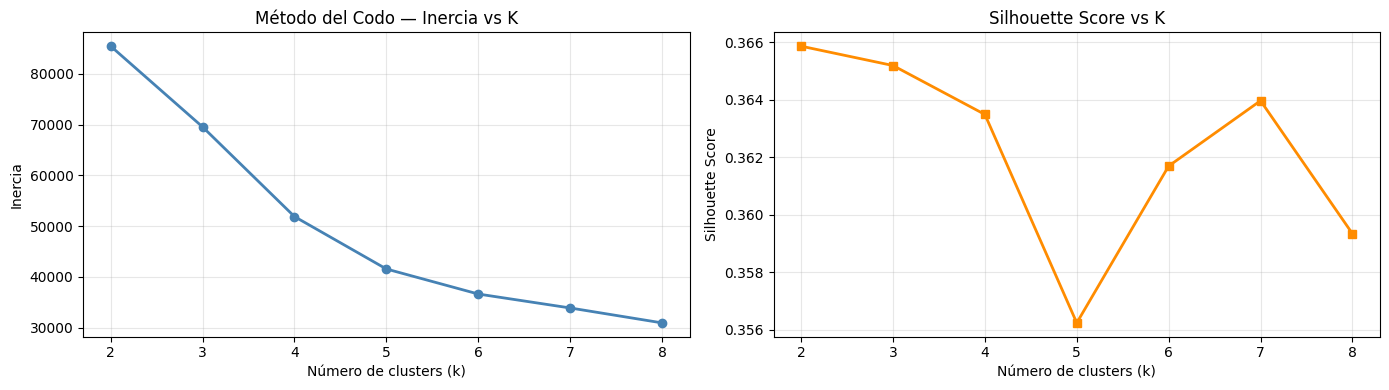

K óptimo (Silhouette): 2  →  Score = 0.3659


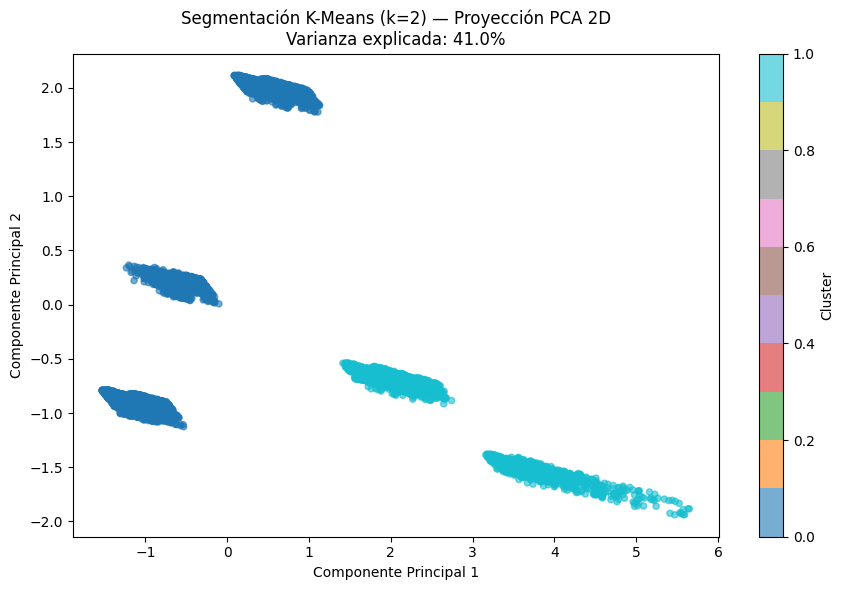


=== Perfil promedio por cluster ===
         edad_promedio  pct_masculino  year_promedio  freq_comuna_rel  tasa_hospitaliz
cluster                                                                               
0               21.064          0.328       2016.292            0.057            0.638
1               47.737          0.432       2016.382            0.055            0.675

Silhouette Score final (k=2): 0.3659


In [9]:
# ── Método del Codo y Silhouette ─────────────────────────────
K_range     = range(2, 9)
inertias    = []
silhouettes = []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, km.labels_))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(list(K_range), inertias, 'o-', color='steelblue', linewidth=2)
axes[0].set_title('Método del Codo — Inercia vs K')
axes[0].set_xlabel('Número de clusters (k)')
axes[0].set_ylabel('Inercia')
axes[0].grid(alpha=0.3)

axes[1].plot(list(K_range), silhouettes, 's-', color='darkorange', linewidth=2)
axes[1].set_title('Silhouette Score vs K')
axes[1].set_xlabel('Número de clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── K óptimo por Silhouette ───────────────────────────────────
k_optimo = list(K_range)[silhouettes.index(max(silhouettes))]
sil_optimo = max(silhouettes)
print(f"K óptimo (Silhouette): {k_optimo}  →  Score = {sil_optimo:.4f}")

# ── Modelo final ──────────────────────────────────────────────
km_final = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
km_final.fit(X_scaled)

# Visualización PCA 2D
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)
fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(coords[:, 0], coords[:, 1], c=km_final.labels_, cmap='tab10', alpha=0.6, s=20)
plt.colorbar(sc, ax=ax, label='Cluster')
ax.set_title(f'Segmentación K-Means (k={k_optimo}) — Proyección PCA 2D\nVarianza explicada: {pca.explained_variance_ratio_.sum()*100:.1f}%')
ax.set_xlabel('Componente Principal 1')
ax.set_ylabel('Componente Principal 2')
plt.tight_layout()
plt.show()

# ── Perfil por cluster ────────────────────────────────────────
clusters_df = X.copy()
clusters_df['cluster'] = km_final.labels_
clusters_df['target']  = y.values

print(f"\n=== Perfil promedio por cluster ===")
perfil_clusters = clusters_df.groupby('cluster')[['edad', 'sexo_enc', 'year', 'freq_comuna', 'target']].mean().round(3)
perfil_clusters.columns = ['edad_promedio', 'pct_masculino', 'year_promedio', 'freq_comuna_rel', 'tasa_hospitaliz']
print(perfil_clusters.to_string())
print(f"\nSilhouette Score final (k={k_optimo}): {sil_optimo:.4f}")

---
## Sección 10 — Evaluación comparativa e interpretación de resultados

Fase **Evaluación** de CRISP-DM. Se comparan los 4 modelos con:

| Métrica | Clasificación |
|---------|--------------|
| **Accuracy** | % de predicciones correctas totales |
| **Precisión** | De los que predijo hospitalizado, ¿cuántos lo eran? |
| **Recall** | De los hospitalizados reales, ¿cuántos encontró? |
| **F1-Score** | Media armónica Precisión–Recall (criterio de selección) |
| **ROC-AUC** | Capacidad discriminativa general |
| **CV-F1** | F1 promedio en validación cruzada 5-fold (generalización) |

  COMPARACIÓN DE MODELOS DE CLASIFICACIÓN
                     Accuracy  Precision  Recall  F1-Score  ROC-AUC  CV-F1 (5k)
Modelo                                                                         
Regresion Logistica    0.6445     0.6445  1.0000    0.7838   0.5186      0.7839
Arbol de Decision      0.6372     0.6511  0.9417    0.7699   0.5595      0.7738
Random Forest          0.6442     0.6495  0.9728    0.7790   0.5435      0.7805
KNN                    0.6084     0.6640  0.7945    0.7234   0.5333      0.7199

★ MEJOR MODELO (F1): Regresion Logistica  →  F1 = 0.7838


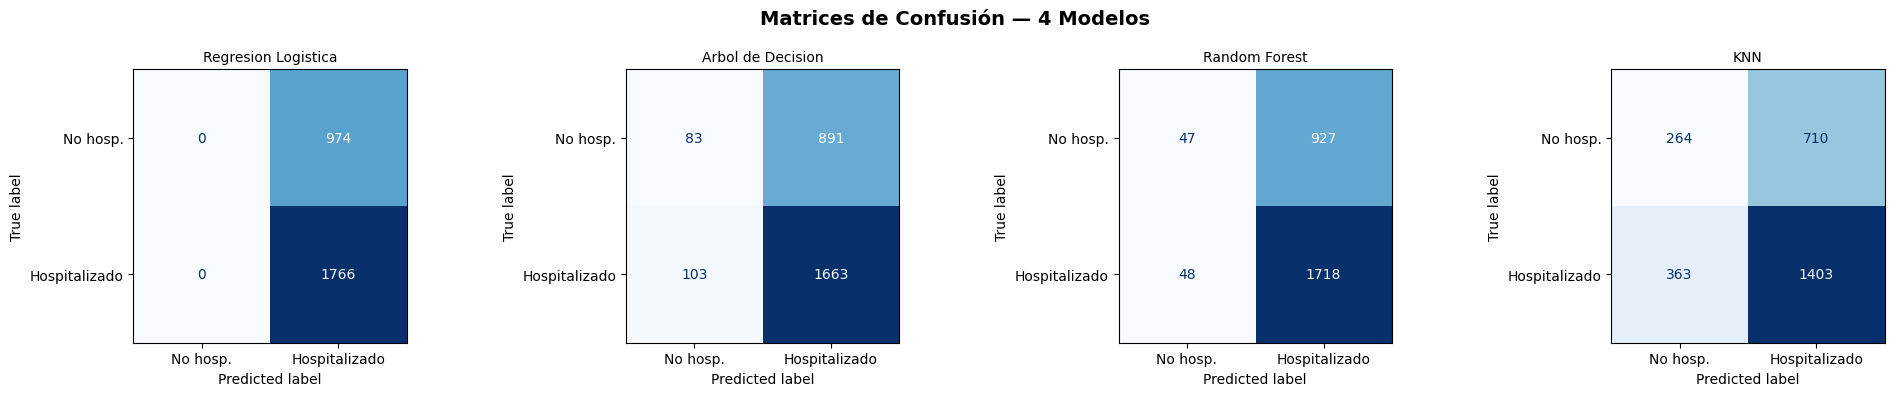

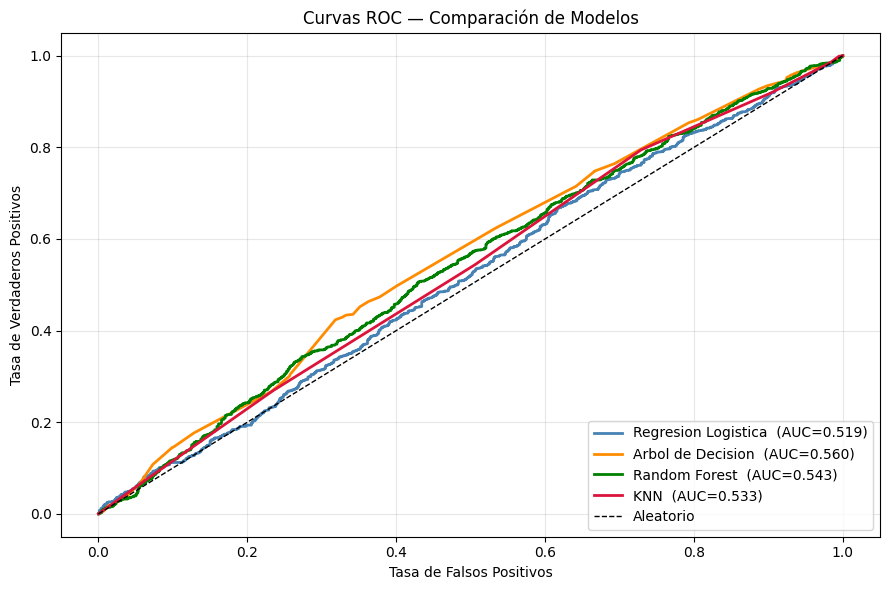

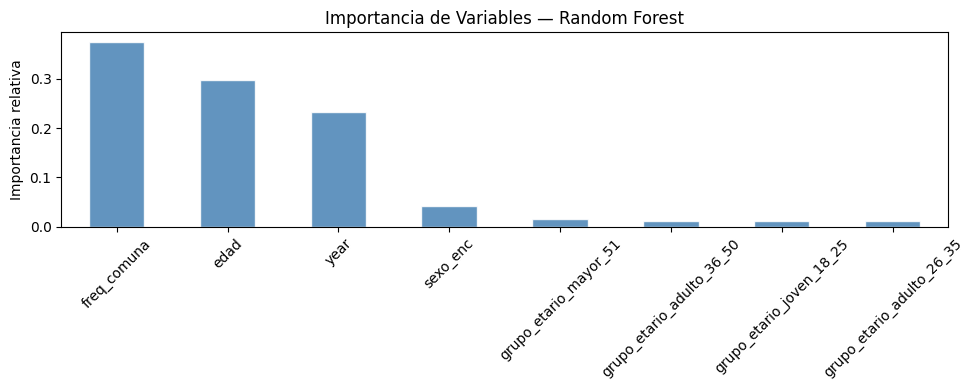


=== Reporte detallado: Regresion Logistica ===
                  precision    recall  f1-score   support

No hospitalizado       0.00      0.00      0.00       974
   Hospitalizado       0.64      1.00      0.78      1766

        accuracy                           0.64      2740
       macro avg       0.32      0.50      0.39      2740
    weighted avg       0.42      0.64      0.51      2740



In [10]:
# ── Tabla comparativa ────────────────────────────────────────
tabla = pd.DataFrame([
    {
        'Modelo':    n,
        'Accuracy':  v['accuracy'],
        'Precision': v['precision'],
        'Recall':    v['recall'],
        'F1-Score':  v['f1'],
        'ROC-AUC':   v['roc_auc'],
        'CV-F1 (5k)':v['cv_f1']
    }
    for n, v in resultados.items()
]).set_index('Modelo').round(4)

print("=" * 70)
print("  COMPARACIÓN DE MODELOS DE CLASIFICACIÓN")
print("=" * 70)
print(tabla.to_string())

mejor_nombre = tabla['F1-Score'].idxmax()
print(f"\n★ MEJOR MODELO (F1): {mejor_nombre}  →  F1 = {tabla.loc[mejor_nombre,'F1-Score']:.4f}")

# ── Matrices de confusión ─────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle('Matrices de Confusión — 4 Modelos', fontsize=14, fontweight='bold')
for ax, (nombre, datos) in zip(axes, resultados.items()):
    cm = confusion_matrix(y_test, datos['y_pred'])
    ConfusionMatrixDisplay(cm, display_labels=['No hosp.','Hospitalizado']).plot(
        ax=ax, colorbar=False, cmap='Blues'
    )
    ax.set_title(nombre, fontsize=10)
plt.tight_layout()
plt.show()

# ── Curvas ROC ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 6))
colors_roc = ['steelblue', 'darkorange', 'green', 'crimson']
for (nombre, datos), color in zip(resultados.items(), colors_roc):
    if datos['y_proba'] is not None:
        fpr, tpr, _ = roc_curve(y_test, datos['y_proba'])
        ax.plot(fpr, tpr, lw=2, color=color, label=f"{nombre}  (AUC={datos['roc_auc']:.3f})")
ax.plot([0,1],[0,1], 'k--', lw=1, label='Aleatorio')
ax.set_xlabel('Tasa de Falsos Positivos')
ax.set_ylabel('Tasa de Verdaderos Positivos')
ax.set_title('Curvas ROC — Comparación de Modelos')
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ── Importancia de variables (Random Forest) ─────────────────
rf_model     = resultados['Random Forest']['modelo']
importancias = pd.Series(rf_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 4))
importancias.plot(kind='bar', color='steelblue', ax=ax, edgecolor='white', alpha=0.85)
ax.set_title('Importancia de Variables — Random Forest')
ax.set_ylabel('Importancia relativa')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# ── Reporte completo del mejor modelo ────────────────────────
print(f"\n=== Reporte detallado: {mejor_nombre} ===")
print(classification_report(
    y_test, resultados[mejor_nombre]['y_pred'],
    target_names=['No hospitalizado', 'Hospitalizado']
))

---
## Sección 11 — Exportación de artefactos y resultados analíticos

Se persisten todos los artefactos necesarios para reproducibilidad y despliegue en la carpeta `output_mineria/`:

| Archivo | Contenido |
|---------|-----------|
| `silver_sivigila.parquet` | Dataset Silver limpio |
| `gold_resumen_comuna.parquet` | Tabla Gold agregada |
| `gold_perfil_riesgo.parquet` | Tabla Gold de perfil individual |
| `comparacion_modelos.csv` | Métricas de los 4 modelos |
| `modelo_clasificacion.pkl` | Mejor modelo serializado |
| `scaler.pkl` | Escalador StandardScaler |
| `modelo_kmeans.pkl` | Modelo K-Means final |

In [11]:
# ── Guardar artefactos ────────────────────────────────────────
tabla.to_csv(OUTPUT_DIR / "comparacion_modelos.csv")

mejor_modelo_obj = resultados[mejor_nombre]['modelo']
with open(OUTPUT_DIR / "modelo_clasificacion.pkl", "wb") as f:
    pickle.dump(mejor_modelo_obj, f)

with open(OUTPUT_DIR / "scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

with open(OUTPUT_DIR / "modelo_kmeans.pkl", "wb") as f:
    pickle.dump(km_final, f)

# Guardar metadata del experimento
metadata = {
    'mejor_modelo': mejor_nombre,
    'f1_mejor':     float(tabla.loc[mejor_nombre, 'F1-Score']),
    'roc_auc_mejor':float(tabla.loc[mejor_nombre, 'ROC-AUC']),
    'k_clusters':   int(k_optimo),
    'silhouette':   float(sil_optimo),
    'n_train':      int(len(X_train)),
    'n_test':       int(len(X_test)),
    'features':     feature_cols,
}
pd.Series(metadata).to_json(OUTPUT_DIR / "metadata_experimento.json", indent=2)

print("=== Artefactos exportados ===\n")
for p in sorted(OUTPUT_DIR.iterdir()):
    size_kb = p.stat().st_size / 1024
    print(f"  {p.name:45s}  {size_kb:7.1f} KB")

=== Artefactos exportados ===

  comparacion_modelos.csv                            0.3 KB
  gold_perfil_riesgo.parquet                       120.3 KB
  gold_resumen_comuna.parquet                        8.8 KB
  metadata_experimento.json                          0.4 KB
  modelo_clasificacion.pkl                           1.0 KB
  modelo_kmeans.pkl                                 54.4 KB
  scaler.pkl                                         0.8 KB
  silver_sivigila.parquet                          254.4 KB


---
## Sección 12 — Consultas SQL para consumo analítico (Amazon Athena)

Estas consultas operan sobre las tablas **Gold** registradas en el Catálogo de Glue y disponibles en Athena. Están listas para copiar y ejecutar directamente en la consola de Athena (una sentencia a la vez).

```sql
-- ─────────────────────────────────────────────────────────────
-- CONSULTA 1: Comunas con mayor número de casos por año
-- ─────────────────────────────────────────────────────────────
SELECT
    comuna,
    year,
    total_casos,
    total_hospitalizados,
    pct_hospitalizados,
    edad_promedio
FROM sivigila_resumen_comuna
ORDER BY year DESC, total_casos DESC
LIMIT 20;


-- ─────────────────────────────────────────────────────────────
-- CONSULTA 2: Proporción de hospitalización por sexo
-- ─────────────────────────────────────────────────────────────
SELECT
    year,
    SUM(casos_masculino)                                       AS total_masculino,
    SUM(casos_femenino)                                        AS total_femenino,
    ROUND(SUM(casos_masculino)*100.0 / SUM(total_casos), 1)   AS pct_masculino,
    ROUND(SUM(casos_femenino)*100.0  / SUM(total_casos), 1)   AS pct_femenino
FROM sivigila_resumen_comuna
GROUP BY year
ORDER BY year;


-- ─────────────────────────────────────────────────────────────
-- CONSULTA 3: Distribución por nivel de riesgo
-- ─────────────────────────────────────────────────────────────
SELECT
    nivel_riesgo,
    COUNT(*)                                     AS total_pacientes,
    AVG(edad)                                    AS edad_promedio,
    SUM(CASE WHEN pac_hos = 1 THEN 1 ELSE 0 END) AS hospitalizados,
    ROUND(
        SUM(CASE WHEN pac_hos = 1 THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1
    )                                            AS pct_hospitalizados
FROM sivigila_perfil_riesgo
GROUP BY nivel_riesgo
ORDER BY nivel_riesgo;


-- ─────────────────────────────────────────────────────────────
-- CONSULTA 4: Top 10 comunas con mayor tasa de hospitalización
-- (mínimo 20 casos para evitar distorsión estadística)
-- ─────────────────────────────────────────────────────────────
SELECT
    comuna,
    SUM(total_casos)          AS total_casos,
    SUM(total_hospitalizados) AS total_hospitalizados,
    ROUND(
        SUM(total_hospitalizados) * 100.0 / SUM(total_casos), 1
    )                         AS tasa_hospitalizacion
FROM sivigila_resumen_comuna
GROUP BY comuna
HAVING SUM(total_casos) >= 20
ORDER BY tasa_hospitalizacion DESC
LIMIT 10;


-- ─────────────────────────────────────────────────────────────
-- CONSULTA 5: Tendencia anual de casos totales
-- ─────────────────────────────────────────────────────────────
SELECT
    year,
    SUM(total_casos)          AS casos_total,
    SUM(total_hospitalizados) AS hospitalizados_total,
    ROUND(AVG(edad_promedio), 1) AS edad_promedio_global
FROM sivigila_resumen_comuna
GROUP BY year
ORDER BY year;
```

---
## Interpretación y Valor de Negocio (CRISP-DM — Fase de Despliegue)

Los resultados de este proyecto permiten:

1. **Priorización territorial**: identificar las comunas con mayores tasas de incidencia y hospitalización para focalizar recursos y atención preventiva.

2. **Perfil de población vulnerable**: la combinación de edad, sexo y frecuencia comunal permite caracterizar los grupos que concentran mayor riesgo relativo.

3. **Modelo predictivo operacional**: el mejor modelo de clasificación puede integrarse como un módulo de apoyo a la triage clínica, estimando probabilidad de hospitalización ante un nuevo registro.

4. **Segmentación para intervenciones diferenciadas**: los clusters de K-Means permiten diseñar estrategias de intervención adaptadas al perfil de cada grupo, en lugar de acciones homogéneas.

5. **Trazabilidad del pipeline**: la arquitectura Bronze → Silver → Gold garantiza que los datos analíticos tengan origen trazable, calidad verificada y estructura reproducible.

> **Limitación reconocida**: una proporción alta de las variables clínicas y psicosociales del dataset contiene el marcador SD (sin dato), lo que restringe el poder predictivo de los modelos actuales. La mejora de la cobertura de estas variables en la fuente SIVIGILA incrementaría significativamente la capacidad discriminativa de los modelos.